<a href="https://www.kaggle.com/code/sunnykumar001/house-loan?scriptVersionId=350471289" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np 
import pandas as pd 

import os
a=[]
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [2]:
import kagglehub
path = kagglehub.competition_download('home-credit-default-risk')
print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/home-credit-default-risk


In [3]:
import pandas as pd 
import numpy as np
from pathlib import Path
from time import time
from zipfile import ZipFile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.preprocessing import (StandardScaler,
                                   OneHotEncoder)
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import spl
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score
)

In [4]:
for dirpath, dirnames, filenames in os.walk(path):
    print(f"Current Directory: {dirpath}")
    print(f"Subdirectories: {dirnames}")
    print(f"Files: {filenames}\n")

Current Directory: /kaggle/input/competitions/home-credit-default-risk
Subdirectories: []
Files: ['sample_submission.csv', 'bureau_balance.csv', 'POS_CASH_balance.csv', 'application_train.csv', 'HomeCredit_columns_description.csv', 'application_test.csv', 'previous_application.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'bureau.csv']



In [5]:
data = Path('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
train_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
train_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


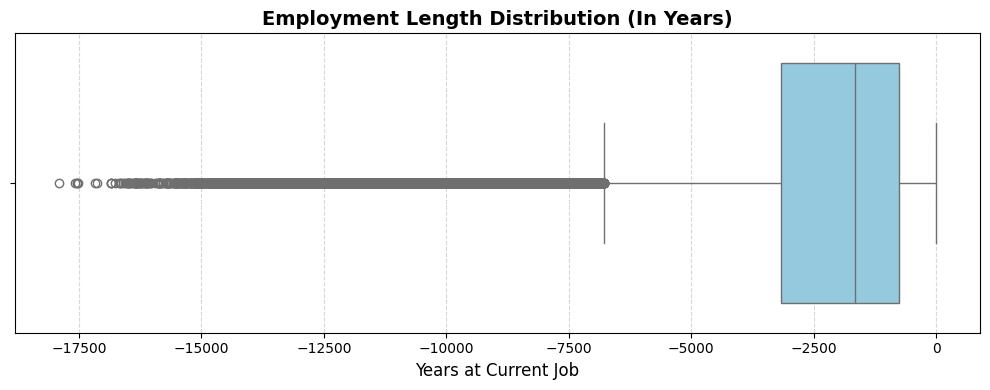

In [6]:
train_df["DAYS_EMPLOYED"] = train_df["DAYS_EMPLOYED"].replace(365243, np.nan)

plt.figure(figsize=(10, 4))
sns.boxplot(data=train_df, x="DAYS_EMPLOYED", color="skyblue")

plt.title(
    "Employment Length Distribution (In Years)", fontsize=14, fontweight="bold"
)
plt.xlabel("Years at Current Job", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
train_df["DAYS_EMPLOYED"].isnull().mean()

np.float64(0.18007160719453938)

In [8]:
# train_df.drop("DAYS_EMPLOYED_CLEANED",axis=1,inplace=True,errors="ignore")
# train_df.drop("DAYS_EMPLOYED",axis=1,inplace=True,errors="ignore")


In [9]:
def rem_null(df:pd.DataFrame) -> pd.DataFrame:
    df_numeric = df.select_dtypes(include="number").copy()
    df_cat = df.select_dtypes(include="object").copy()

    missing_pct = df_numeric.isnull().mean() * 100
    high_null_cols = missing_pct[missing_pct > 20].index
    # high_null_cols
    print(f"Before dropping null : {df_numeric.shape[1]}")
    df_numeric.drop(labels=high_null_cols, axis=1,inplace=True)
    print(f"after dropping null : {df_numeric.shape[1]}")

    if not df_cat.empty:
        missing_pct = df_cat.isnull().mean() * 100
        high_null_cols = missing_pct[missing_pct > 1].index
        # high_null_cols
        print(f"Before dropping null : {df_cat.shape[1]}")
        df_cat.drop(labels=high_null_cols, axis=1,inplace=True)
        print(f"after dropping null : {df_cat.shape[1]}")
    data = pd.concat([df_numeric,df_cat],axis=1)
    return data

In [10]:
null_counts = train_df.select_dtypes("number").isnull().sum()

missing_data = null_counts[null_counts > 0].sort_values(ascending=False)

print(missing_data)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 62, dtype: int64


<Axes: >

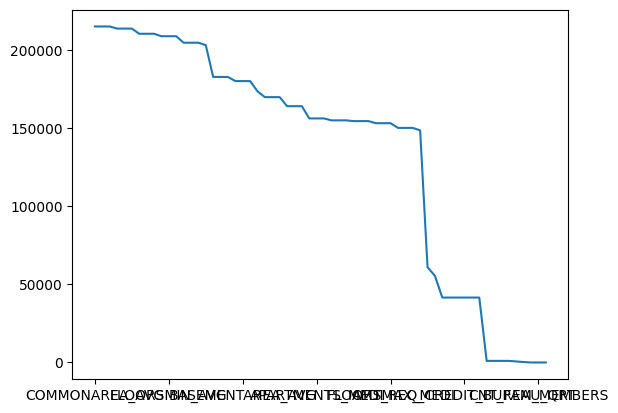

In [11]:
missing_data.abs().sort_values(ascending=False).plot(kind="line")
# sns.heatmap()

In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(66), int64(40), object(16)
memory usage: 286.2+ MB


In [13]:
n_rows , n_columns = train_df.shape

numeric_data = train_df.select_dtypes(include=["number"]).columns
categorical_data = train_df.select_dtypes(include=['object']).columns

print(f"DATAFRAME :{data.name} size :{(data.stat().st_size) / 1024**2:.0f} MB")
print(f"{n_rows} ROWS x {n_columns} COLUMNS")
print(f"NUMERIC : {len(numeric_data)}")
print(f"CATOGORICAL : {len(categorical_data)}")
print(f"SK_ID_CURR : {train_df.SK_ID_CURR.nunique()} "
      f"(unique : {train_df.SK_ID_CURR.is_unique})")

DATAFRAME :application_train.csv size :158 MB
307511 ROWS x 122 COLUMNS
NUMERIC : 106
CATOGORICAL : 16
SK_ID_CURR : 307511 (unique : True)


In [14]:
test_data = Path("/kaggle/input/competitions/home-credit-default-risk/application_test.csv")
test_df = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/application_test.csv")

In [15]:
n_rows , n_columns = test_df.shape

numeric_data = test_df.select_dtypes(include=["number"]).columns
categorical_data = test_df.select_dtypes(include=['object']).columns

print(f"DATAFRAME :{test_data.name} size :{(test_data.stat().st_size) / 1024**2:.0f} MB")
print(f"{n_rows} ROWS x {n_columns} COLUMNS")
print(f"NUMERIC : {len(numeric_data)}")
print(f"CATOGORICAL : {len(categorical_data)}")
print(f"SK_ID_CURR : {test_df.SK_ID_CURR.nunique()} "
      f"(unique : {test_df.SK_ID_CURR.is_unique})")

DATAFRAME :application_test.csv size :25 MB
48744 ROWS x 121 COLUMNS
NUMERIC : 105
CATOGORICAL : 16
SK_ID_CURR : 48744 (unique : True)


In [16]:
TARGET = train_df["TARGET"]
positive_rate = TARGET.mean()
imbalance = (1-positive_rate)/positive_rate

count = TARGET.value_counts().sort_index()
print("Target Distribution")
print(f"On_time payment        : {count[0]:>7,}    {(1-positive_rate)*100:5>.2f}%")
print(f"delayed                : {count[1]:>7,}    {positive_rate*100:5>.2f}% ")
print(f"imablance (ratio diff) : {imbalance:5>.2f}%")

Dummy = DummyClassifier(strategy="most_frequent").fit(train_df["AMT_CREDIT"],TARGET)
predict_prob = Dummy.predict_proba(train_df["AMT_CREDIT"])
acc = Dummy.predict(train_df["AMT_CREDIT"])
rou = Dummy.predict_proba(train_df["AMT_CREDIT"])[:,0]
print(f"Accuracy      : {accuracy_score(TARGET,acc):>6.2f}")
print(f"rou_auc_score : {roc_auc_score(TARGET,rou):>6.2f}")

Target Distribution
On_time payment        : 282,686    91.93%
delayed                :  24,825    8.07% 
imablance (ratio diff) : 11.39%
Accuracy      :   0.92
rou_auc_score :   0.50


/tmp/ipykernel_16/1175555325.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/tmp/ipykernel_16/1175555325.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


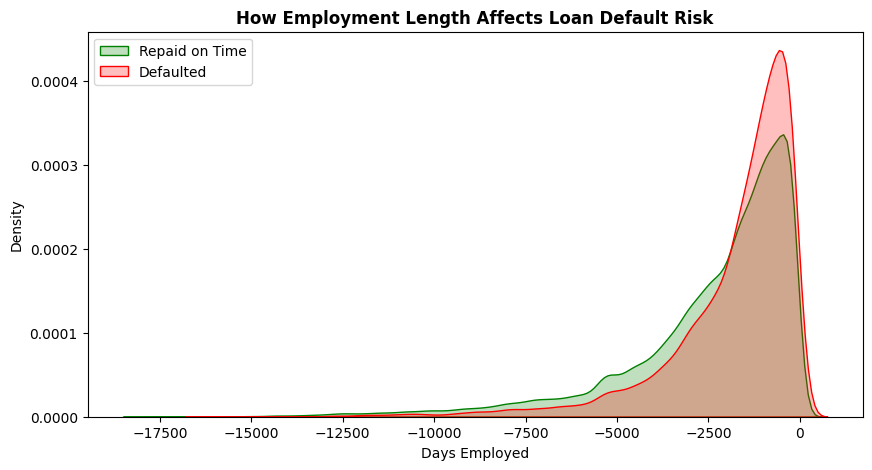

In [17]:
plt.figure(figsize=(10, 5))

# Plot overlaying density curves for both target classes
sns.kdeplot(
    data=train_df[train_df["TARGET"] == 0],
    x="DAYS_EMPLOYED",
    label="Repaid on Time",
    shade=True,
    color="g",
)
sns.kdeplot(
    data=train_df[train_df["TARGET"] == 1],
    x="DAYS_EMPLOYED",
    label="Defaulted",
    shade=True,
    color="r",
)

plt.title("How Employment Length Affects Loan Default Risk", fontweight="bold")
plt.xlabel("Days Employed")
plt.ylabel("Density")
plt.legend()
plt.show()

In [18]:
def merging_df(main_df:pd.DataFrame,
               agg_df,
               by:str):
    final_df = main_df.copy()
    if isinstance(agg_df,list):
        for i in agg_df:
            final_df = main_df.merge(i,on=by,how="left")
            return final_df
    else:
        final_df = main_df.merge(agg_df,on=by,how="left")

        return final_df

In [19]:
new_train_df = rem_null(train_df).copy()
test_df = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/application_test.csv")


Before dropping null : 106
after dropping null : 61
Before dropping null : 16
after dropping null : 11


In [20]:
train_df_colm = new_train_df.drop("TARGET",axis=1).columns

In [21]:

test_df = test_df[train_df_colm]

In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 71 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SK_ID_CURR                   48744 non-null  int64  
 1   CNT_CHILDREN                 48744 non-null  int64  
 2   AMT_INCOME_TOTAL             48744 non-null  float64
 3   AMT_CREDIT                   48744 non-null  float64
 4   AMT_ANNUITY                  48720 non-null  float64
 5   AMT_GOODS_PRICE              48744 non-null  float64
 6   REGION_POPULATION_RELATIVE   48744 non-null  float64
 7   DAYS_BIRTH                   48744 non-null  int64  
 8   DAYS_EMPLOYED                48744 non-null  int64  
 9   DAYS_REGISTRATION            48744 non-null  float64
 10  DAYS_ID_PUBLISH              48744 non-null  int64  
 11  FLAG_MOBIL                   48744 non-null  int64  
 12  FLAG_EMP_PHONE               48744 non-null  int64  
 13  FLAG_WORK_PHONE 

In [23]:
len(test_df.select_dtypes("object").count())

11

In [24]:
# for name,df in datasets.items():
#     num= df.select_dtypes("number").count()
#     cat= df.select_dtypes("object").count()
#     print(f"{name:<25} : num {len(num):>5} cat {len(cat):>5}")

In [25]:
# prev = merging_df(previous_application,[pos,installments_payments,credit],by="SK_ID_PREV")

In [26]:
# prev["SK_ID_CURR"] = prev["SK_ID_CURR_x"]
# prev.drop("SK_ID_CURR_x",axis = 1)

In [27]:
# train_merged_df = merging_df(train_df,[prev,bureau],by="SK_ID_CURR")
# test_merged_df = merging_df(test_df,[prev,bureau],by="SK_ID_CURR")

In [28]:
# def null_val(df:pd.DataFrame):
#     df.isnull()

In [29]:
import pandas as pd
def aggregating_data(df:pd.DataFrame,
                         id_colmn : str,
                         df_agg: str|list =["mean"],
                         cat_agg_param=["sum"],
                         cat_colm:bool = False,
                         cat_colm_df = list,
                         drop_colmn: str | list = None,
                         if_drop : bool = False):
    final_df = df.copy()
    if if_drop:
        final_df.drop(columns=[drop_colmn], errors='ignore')
        print("removed")

    num_df = final_df.select_dtypes(include="number")
    cat_df = final_df.select_dtypes(include="object")
    num_colm_df = num_df.columns.to_list()
    if id_colmn in num_colm_df:
        num_colm_df.remove(id_colmn)
    if drop_colmn in num_colm_df:
        num_colm_df.remove(drop_colmn)
    if cat_colm:
        cat_colm_df
        print("Got colmn")
    else:
        cat_colm_df = False
    print("agg_started")



    if num_colm_df:
        print("grouping started")
        agg_data = final_df.groupby(id_colmn)[num_colm_df].agg(df_agg)
        agg_data.columns = [f"{c}_{s}".upper() for c,s in agg_data.columns]
        agg_data.reset_index(inplace=True)
        print("num_done")

    if cat_colm_df:
        print("cat_group started")
        dummies = pd.get_dummies(cat_df[cat_colm_df])
        dummies[id_colmn] = final_df[id_colmn]
        cat_agg = dummies.groupby(id_colmn).agg(cat_agg_param)
        cat_agg.columns = [f"{c}_{s}".upper() for c,s in cat_agg.columns]
        cat_agg.reset_index(inplace=True)
        agg_data = agg_data.merge(cat_agg,how="left",on=id_colmn)

    return agg_data

In [30]:
import pandas as pd
import gc

def aggregate_and_merge(main_df_path:pd.DataFrame, output_name="final_dataset.parquet"):
    print("Starting data assembly...")
    

    main_df = main_df_path.copy()
    
    print("Processing Bureau and Bureau Balance...")
    bureau = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/bureau.csv")
    bureau_balance = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv")
    print("read csv")
    # Aggregate bureau balance to bureau level first (on SK_ID_BUREAU)
    bb_agg = aggregating_data(bureau_balance,id_colmn="SK_ID_BUREAU",drop_colmn="SK_ID_CURR",cat_colm=False)
    # bb_agg.columns = ['_'.join(col).strip() for col in bb_agg.columns.values]
    bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
    print("bureau agg done")
    # Aggregate bureau to client level (on SK_ID_CURR)
    bureau_agg = bureau.drop(columns=['SK_ID_BUREAU'])
    
    
    # Merge to main and clear memory
    main_df = main_df.merge(bureau_agg, on='SK_ID_CURR', how='left')
    del bureau, bureau_balance, bb_agg, bureau_agg; gc.collect()

    print("Processing Previous Applications...")
    prev = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/previous_application.csv")
    prev_agg = aggregating_data(prev,id_colmn="SK_ID_CURR",if_drop=True,drop_colmn='SK_ID_PREV',cat_colm=True,cat_colm_df=["NAME_YIELD_GROUP"])
    print("done")
    main_df = main_df.merge(prev_agg, on='SK_ID_CURR', how='left')
    del prev, prev_agg; gc.collect()

    for table_name, path in [
        ("POS", "/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv"),
        ("INSTAL", "/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv"),
        ("CREDIT", "/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv")
    ]:
        print(f"Processing {table_name}...")
        child_df = pd.read_csv(path)
        
        # Group directly by client ID, dropping the sub-contract ID to preserve information
        child_agg = aggregating_data(child_df,id_colmn="SK_ID_CURR",if_drop=True,drop_colmn='SK_ID_PREV',cat_colm=False)
        
        main_df = main_df.merge(child_agg, on='SK_ID_CURR', how='left')
        del child_df, child_agg; gc.collect()

    print(f"Finished! Final Shape: {main_df.shape}")
    return main_df

train_final = aggregate_and_merge(new_train_df)
test_final = aggregate_and_merge(test_df)

Starting data assembly...
Processing Bureau and Bureau Balance...
read csv
agg_started
grouping started
num_done
bureau agg done
Processing Previous Applications...
removed
Got colmn
agg_started
grouping started
num_done
cat_group started
done
Processing POS...
removed
agg_started
grouping started
num_done
Processing INSTAL...
removed
agg_started
grouping started
num_done
Processing CREDIT...
removed
agg_started
grouping started
num_done
Finished! Final Shape: (1509345, 143)
Starting data assembly...
Processing Bureau and Bureau Balance...
read csv
agg_started
grouping started
num_done
bureau agg done
Processing Previous Applications...
removed
Got colmn
agg_started
grouping started
num_done
cat_group started
done
Processing POS...
removed
agg_started
grouping started
num_done
Processing INSTAL...
removed
agg_started
grouping started
num_done
Processing CREDIT...
removed
agg_started
grouping started
num_done
Finished! Final Shape: (257527, 142)


In [31]:
print(train_final.columns)
train_final.head(5)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY_x', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'AMT_RECEIVABLE_PRINCIPAL_MEAN', 'AMT_RECIVABLE_MEAN',
       'AMT_TOTAL_RECEIVABLE_MEAN', 'CNT_DRAWINGS_ATM_CURRENT_MEAN',
       'CNT_DRAWINGS_CURRENT_MEAN', 'CNT_DRAWINGS_OTHER_CURRENT_MEAN',
       'CNT_DRAWINGS_POS_CURRENT_MEAN', 'CNT_INSTALMENT_MATURE_CUM_MEAN',
       'SK_DPD_MEAN_y', 'SK_DPD_DEF_MEAN_y'],
      dtype='object', length=143)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY_x,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,AMT_RECEIVABLE_PRINCIPAL_MEAN,AMT_RECIVABLE_MEAN,AMT_TOTAL_RECEIVABLE_MEAN,CNT_DRAWINGS_ATM_CURRENT_MEAN,CNT_DRAWINGS_CURRENT_MEAN,CNT_DRAWINGS_OTHER_CURRENT_MEAN,CNT_DRAWINGS_POS_CURRENT_MEAN,CNT_INSTALMENT_MATURE_CUM_MEAN,SK_DPD_MEAN_y,SK_DPD_DEF_MEAN_y
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
train = train_final.copy()
train.drop(["TARGET","EXT_SOURCE_3","EXT_SOURCE_2"],axis=1,inplace=True)
x = train
y=train_final.TARGET

In [33]:
x.columns == "TARGET"

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.90)

In [35]:
x_num = x_train.select_dtypes("number")

In [36]:
correlations = pd.concat([x_num, y_train], axis=1).corr()['TARGET'].abs().sort_values(ascending=False)
print(correlations.head(10))

TARGET                           1.000000
CNT_DRAWINGS_ATM_CURRENT_MEAN    0.104463
AMT_BALANCE_MEAN                 0.084273
AMT_TOTAL_RECEIVABLE_MEAN        0.083679
AMT_RECIVABLE_MEAN               0.083663
AMT_RECEIVABLE_PRINCIPAL_MEAN    0.083164
AMT_INST_MIN_REGULARITY_MEAN     0.073412
CNT_DRAWINGS_CURRENT_MEAN        0.073257
DAYS_EMPLOYED                    0.070062
DAYS_BIRTH                       0.067714
Name: TARGET, dtype: float64


In [37]:
len(x_train),len(x_test)

(1358410, 150935)

In [38]:
numeric_data = Pipeline(steps=[
    ("SimpleImputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())]
)
cat_data = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent",fill_value="missing")),
    ("one",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
])
column_Transformer = ColumnTransformer(transformers=[
    ("num",numeric_data,x_train.select_dtypes(include="number").columns.to_list()),
    ("cat",cat_data,x_train.select_dtypes(include="object").columns.to_list())
])

whole_process = Pipeline(steps=[
    ("Column_Transformer",column_Transformer),
    ("model",RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_split=10,max_features="sqrt"))
])
model = whole_process.fit(x_train,y_train)
model

Pipeline(steps=[('Column_Transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SK_ID_CURR', 'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT',
                                                   'AMT_ANNUITY_x',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DA...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE',
                                                   'CREDIT_ACTIVE',
                                                   'CREDIT_CURRENCY',
                                                   'CREDIT_TYPE'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_split=10))])

In [39]:
acc = model.predict(x_test)
rou = model.predict_proba(x_test)[:,1]
print(f"Accuracy      : {accuracy_score(y_test,acc):>6.2f}")
print(f"rou_auc_score : {roc_auc_score(y_test,rou):>6.2f}")

# y_pred_probs = best_pipeline.predict_proba(x_valid)[:, 1]

# # 2. Calculate the score using the true validation labels
# actual_score = roc_auc_score(y_valid, y_pred_probs)

# print(f"True Validation ROC-AUC: {actual_score:.4f}")

Accuracy      :   0.92
rou_auc_score :   0.79


In [40]:
from xgboost import XGBClassifier

numeric_data = Pipeline(steps=[
    ("SimpleImputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())]
)
cat_data = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent",fill_value="missing")),
    ("one",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
])
column_Transformer = ColumnTransformer(transformers=[
    ("num",numeric_data,x_train.select_dtypes(include="number").columns.to_list()),
    ("cat",cat_data,x_train.select_dtypes(include="object").columns.to_list())
])

whole_process = Pipeline(steps=[
    ("Column_Transformer",column_Transformer),
    ("model",XGBClassifier(n_estimators=100,verbosity=2,max_depth=5, objective="binary:logistic",learning_rate=0.1,booster="dart"))
])
model1 = whole_process.fit(x_train,y_train)
model1

[05:06:27] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (1358410, 255, 346394550).
[05:06:28] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:29] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:30] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:31] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:33] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:35] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:38] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:41] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:44] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight = 1
[05:06:48] INFO: /__w/xgboost/xgboost/src/gbm/gbtree.cc:910: drop 0 trees, weight

Pipeline(steps=[('Column_Transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SK_ID_CURR', 'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT',
                                                   'AMT_ANNUITY_x',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DA...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [41]:
acc = model1.predict(x_test)
rou = model1.predict_proba(x_test)[:,1]
print(f"Accuracy      : {accuracy_score(y_test,acc):>6.2f}")
print(f"rou_auc_score : {roc_auc_score(y_test,rou):>6.2f}")

Accuracy      :   0.92
rou_auc_score :   0.78


In [42]:
import joblib

joblib.dump(model, 'model.joblib')
import joblib

joblib.dump(model1, 'model1.joblib')   

['model1.joblib']

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

numeric_data = Pipeline(steps=[
    ("SimpleImputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())]
)
cat_data = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent",fill_value="missing")),
    ("one",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
])
column_Transformer = ColumnTransformer(transformers=[
    ("num",numeric_data,x_train.select_dtypes(include="number").columns.to_list()),
    ("cat",cat_data,x_train.select_dtypes(include="object").columns.to_list())
])

whole_process = Pipeline(steps=[
    ("Column_Transformer",column_Transformer),
    ("model",HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
])

param = [
    {
        'model': [HistGradientBoostingClassifier(class_weight='balanced', random_state=42)],
        'model__learning_rate': [0.01],
        'model__max_iter': [100,200],
        'model__max_depth': [5]
    }
]
print(f"Training data shape: {x.shape}")
print(f"Target data shape: {y.shape}")
model2 = RandomizedSearchCV(estimator=whole_process,
                            n_jobs=1,
                            param_distributions=param,
                            n_iter=3,
                            cv=3,
                            verbose=3,
                            random_state=42
                            )
print("\n--- Starting the Grid Search ---")
try:
    model2.fit(x, y)
    print("\n--- Search Completed Successfully! ---")
    print(f"Best Score: {search.best_score_:.4f}")
    
except Exception as e:
    print("\n!!! THE FIT PROCESS CRASHED !!!")
    print(f"The real error is: {e}")
                        


Training data shape: (1509345, 140)
Target data shape: (1509345,)

--- Starting the Grid Search ---
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=3. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV 1/3] END model=HistGradientBoostingClassifier(class_weight='balanced', random_state=42), model__learning_rate=0.01, model__max_depth=5, model__max_iter=100;, score=0.652 total time= 2.6min
[CV 2/3] END model=HistGradientBoostingClassifier(class_weight='balanced', random_state=42), model__learning_rate=0.01, model__max_depth=5, model__max_iter=100;, score=0.645 total time= 2.6min
[CV 3/3] END model=HistGradientBoostingClassifier(class_weight='balanced', random_state=42), model__learning_rate=0.01, model__max_depth=5, model__max_iter=100;, score=0.659 total time= 2.6min
[CV 1/3] END model=HistGradientBoostingClassifier(class_weight='balanced', random_state=42), model__learning_rate=0.01, model__max_depth=5, model__max_iter=200;, score=0.660 total time= 4.4min
[CV 2/3] END model=HistGradientBoostingClassifier(class_weight='balanced', random_state=42), model__learning_rate=0.01, model__max_depth=5, model__max_iter=200;, score=0.663 total time= 4.3min
[CV 3/3] END model=HistGradientBoos

In [44]:
acc = model2.predict(x_test)
rou = model2.predict_proba(x_test)[:,1]
print(f"Accuracy      : {accuracy_score(y_test,acc):>6.2f}")
print(f"rou_auc_score : {roc_auc_score(y_test,rou):>6.2f}")

Accuracy      :   0.67
rou_auc_score :   0.73


In [45]:
acc = model2.predict(x_test)
rou = model2.predict_proba(x_test)[:,1]
print(f"Accuracy      : {accuracy_score(y_test,acc):>6.2f}")
print(f"rou_auc_score : {roc_auc_score(y_test,rou):>6.2f}")

Accuracy      :   0.67
rou_auc_score :   0.73


In [46]:
aa = pd.DataFrame(acc)
aa.value_counts()

0
0    97253
1    53682
Name: count, dtype: int64

In [47]:
abb = model.predict(test_final)

In [48]:
a = pd.DataFrame(abb)
a.value_counts()

0
0    257527
Name: count, dtype: int64